In [1]:
# --- 0) Imports & paths ---
import os, numpy as np, scanpy as sc
from anndata import AnnData
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import umap.umap_ as umap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd

# PyTorch imports
import torch
from torch.utils.data import TensorDataset, DataLoader

# Mixed diffusion imports
from mixed_diffusion.train import train
from mixed_diffusion.models.get_model import get_model
from mixed_diffusion.main_utils import get_device
from mixed_diffusion.config_manager import load_model_config
from mixed_diffusion.model_handler import load_existing_model
from mixed_diffusion.preprocessing.data_transformer import DataTransformer
np.random.seed(42)


Class probabilities: [0.2, 0.2, 0.2, 0.2, 0.2]
Actual class distribution: [2043 2015 2050 1930 1962]
Class proportions: [0.2043 0.2015 0.205  0.193  0.1962]
Class 0: 2043 samples
  Mean (first 5 dims): [ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337]
  Generated data mean (first 5 dims): [ 0.49079708 -0.11840929  0.63192767  1.5432264  -0.24985365]
Class 1: 2015 samples
  Mean (first 5 dims): [-0.56228753 -1.01283112  0.31424733 -0.90802408 -1.4123037 ]
  Generated data mean (first 5 dims): [-0.55000667 -1.03430062  0.28146229 -0.89305517 -1.41443829]
Class 2: 2050 samples
  Mean (first 5 dims): [-0.60170661  1.85227818 -0.01349722 -1.05771093  0.82254491]
  Generated data mean (first 5 dims): [-0.60731139  1.86022271 -0.01048891 -1.06783364  0.83123545]
Class 3: 1930 samples
  Mean (first 5 dims): [-0.71984421 -0.46063877  1.05712223  0.34361829 -1.76304016]
  Generated data mean (first 5 dims): [-0.70865407 -0.45039871  1.05398182  0.34251946 -1.74472838]
Class 4: 1962 s

/opt/homebrew/anaconda3/envs/mixed_diffusion/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


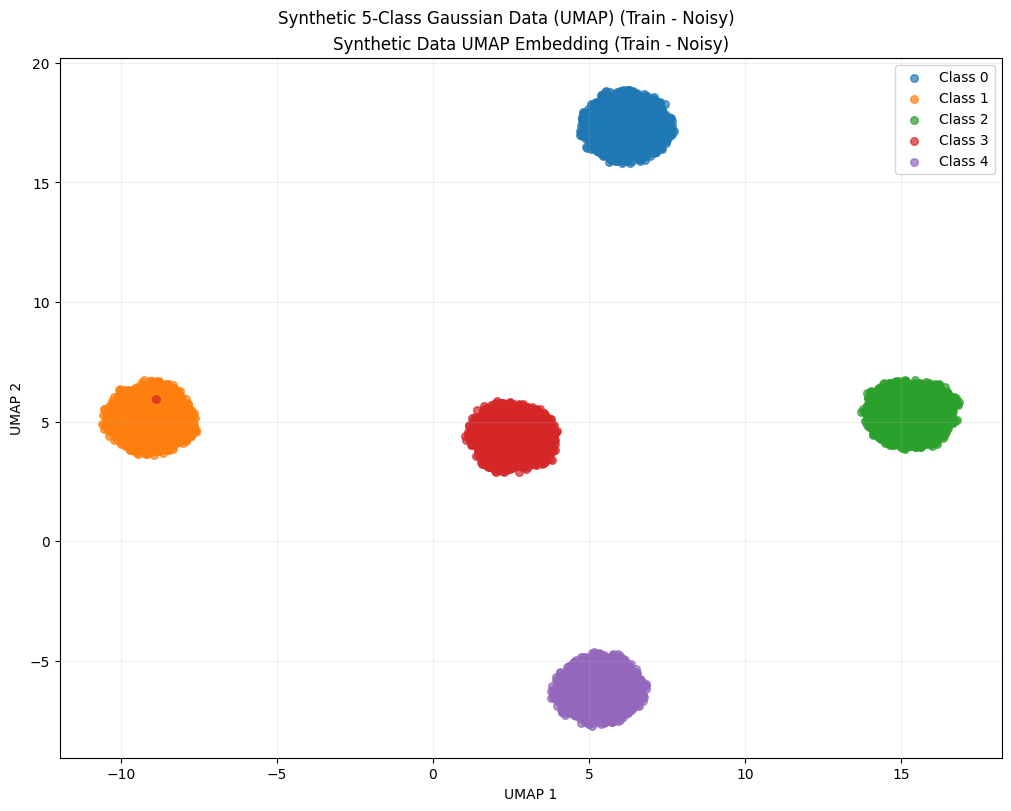

UMAP embedding shape: (8000, 2)
Data points per class: [1634 1612 1640 1544 1570]



/opt/homebrew/anaconda3/envs/mixed_diffusion/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


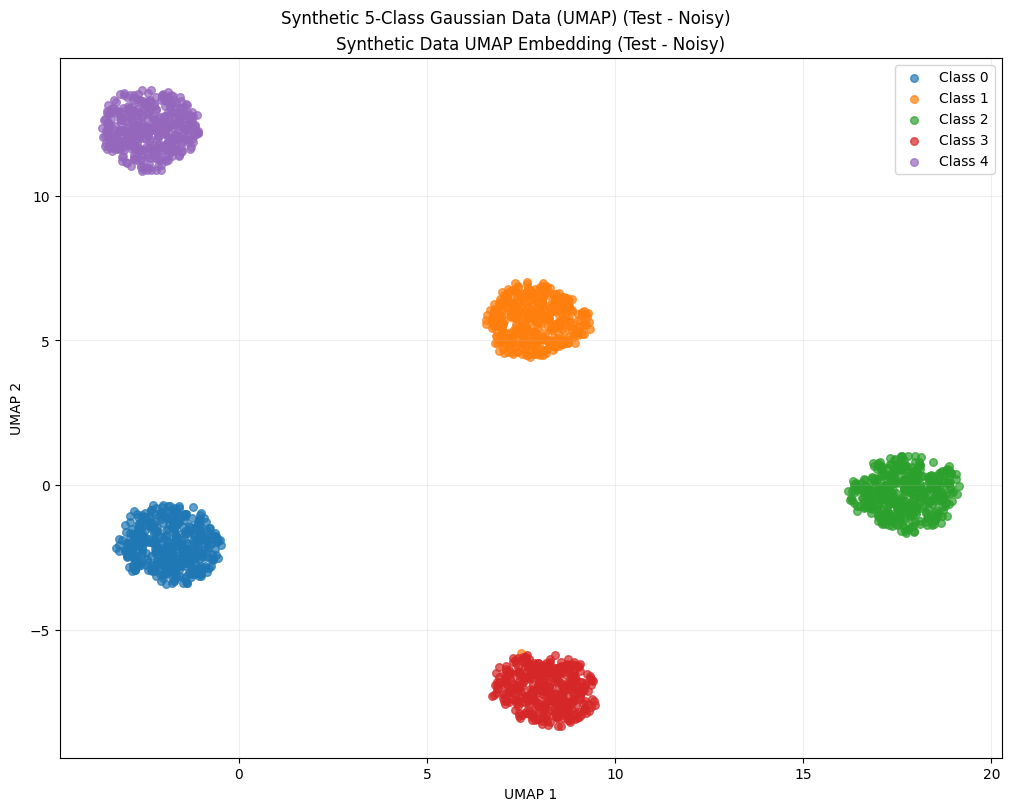

UMAP embedding shape: (2000, 2)
Data points per class: [409 403 410 386 392]

Final data shapes:
X_train_noisy.shape: (8000, 200)
X_test_noisy.shape: (2000, 200)
y_train unique labels: [0 1 2 3 4]
y_test unique labels: [0 1 2 3 4]


In [2]:
# We have five 15d means
means = [np.random.randn(15) for _ in range(5)]
variance = [[.3] * 15 for _ in range(5)]
stds = np.sqrt(variance)

# Sample data from the five Gaussians with labels
np.random.seed(42)  # For reproducibility

n_samples = 10000
n_classes = len(means)

# Equal probability for all 5 classes
class_probs = [1/n_classes] * n_classes  # [0.2, 0.2, 0.2, 0.2, 0.2]

labels = np.random.choice(range(n_classes), size=n_samples, p=class_probs)

print(f"Class probabilities: {class_probs}")
print(f"Actual class distribution: {np.bincount(labels)}")
print(f"Class proportions: {np.bincount(labels) / n_samples}")

# Generate data using multivariate normal distribution
all_data = []
all_labels = []

for i in range(n_classes):
    # Number of samples for this class
    n_class_samples = (labels == i).sum()
    
    # Create covariance matrix (diagonal matrix from variances)
    cov_matrix = np.diag(variance[i])
    
    # Sample from multivariate normal distribution
    class_data = np.random.multivariate_normal(
        mean=means[i], 
        cov=cov_matrix, 
        size=n_class_samples
    )
    
    all_data.append(class_data)
    all_labels.append(np.full(n_class_samples, i))
    
    print(f"Class {i}: {n_class_samples} samples")
    print(f"  Mean (first 5 dims): {np.array(means[i])[:5]}")
    print(f"  Generated data mean (first 5 dims): {class_data.mean(axis=0)[:5]}")
    

U = np.vstack(all_data)

V_rows = 200
V = np.random.multivariate_normal(np.zeros(15), np.eye(15), size=V_rows)

X_true = U @ V.T

# Create labels array from all_labels
y = np.concatenate(all_labels)

print(f"\nBefore shuffling:")
print(f"X_true shape: {X_true.shape}")
print(f"y shape: {y.shape}")
print(f"Unique labels: {np.unique(y)}")
print(f"Label distribution: {np.bincount(y)}")

# Shuffle the data and labels together to mix the classes
shuffle_idx = np.random.permutation(len(X_true))
X_true = X_true[shuffle_idx]
y = y[shuffle_idx]

# Create train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_true, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Maintain class balance across all 5 classes
)

X_train_noisy = X_train + np.random.normal(0, 0.5, X_train.shape)
X_test_noisy = X_test + np.random.normal(0, 1, X_test.shape)

print(f"\nAfter train/test split:")
print(f"Train labels distribution: {np.bincount(y_train)}")
print(f"Test labels distribution: {np.bincount(y_test)}")

def visualize_umap(X, y, title_suffix=""):
    # --- UMAP visualization of synthetic data ---
    # Apply PCA first to reduce dimensionality
    pca = PCA(n_components=15)
    X_pca = pca.fit_transform(X)

    # Then apply UMAP on the PCA-reduced data
    um = umap.UMAP(n_neighbors=15, min_dist=0.3, random_state=0).fit(X_pca)
    emb = um.embedding_

    # --- Plot the UMAP embedding ---
    fig, ax = plt.subplots(1, 1, figsize=(10, 8), constrained_layout=True)
    ax.set_title(f"Synthetic Data UMAP Embedding {title_suffix}")

    import matplotlib.colors as mcolors
    palette = list(mcolors.TABLEAU_COLORS.values())

    # Plot each class with different colors
    unique_labels = np.unique(y)
    for i, label in enumerate(unique_labels):
        mask = y == label
        ax.scatter(emb[mask, 0], emb[mask, 1], 
                s=30, alpha=0.7, 
                c=palette[i % len(palette)], 
                label=f'Class {label}')

    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.grid(True, alpha=0.2)
    ax.legend()

    plt.suptitle(f"Synthetic 5-Class Gaussian Data (UMAP) {title_suffix}")
    plt.show()

    print(f"UMAP embedding shape: {emb.shape}")
    print(f"Data points per class: {np.bincount(y)}")
    print()

visualize_umap(X_train_noisy, y_train, "(Train - Noisy)")
visualize_umap(X_test_noisy, y_test, "(Test - Noisy)")

print(f"Final data shapes:")
print(f"X_train_noisy.shape: {X_train_noisy.shape}")
print(f"X_test_noisy.shape: {X_test_noisy.shape}")
print(f"y_train unique labels: {np.unique(y_train)}")
print(f"y_test unique labels: {np.unique(y_test)}")

In [3]:
# Create train/test split and save in CITEseq format
import pandas as pd

# Save in CITEseq format
# Save data as C_train.npy and C_test.npy
np.save('C_train.npy', X_train_noisy)
np.save('C_test.npy', X_test_noisy)

# Save labels as CSV files (matching CITEseq format)
# Create DataFrame with 'x' column to match CITEseq structure
labels_train_df = pd.DataFrame({'x': y_train})
labels_test_df = pd.DataFrame({'x': y_test})

labels_train_df.to_csv('labels_train.csv', index=False)
labels_test_df.to_csv('labels_test.csv', index=False)

=== Creating Modified Test Set ===
Removing class 4
Original mean for class 4: [-0.47917424 -0.18565898 -1.10633497 -1.19620662  0.81252582]... (first 5 dims)
New mean added: [-0.14235884  2.05722174  0.28326194  1.32981198 -0.15462185]... (first 5 dims)
Modified means now has 5 classes
Modified test class distribution: [399 418 377 387 419]
Modified Class 0: 399 samples
  Corresponds to original class 0
Modified Class 1: 418 samples
  Corresponds to original class 1
Modified Class 2: 377 samples
  Corresponds to original class 2
Modified Class 3: 387 samples
  Corresponds to original class 3
Modified Class 4: 419 samples
  NEW CLASS (not in training)

=== Modified Test Set Summary ===
X_test_modified_noisy shape: (2000, 200)
y_test_modified shape: (2000,)
Unique labels: [0 1 2 3 4]
Label distribution: [399 418 377 387 419]


/opt/homebrew/anaconda3/envs/mixed_diffusion/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


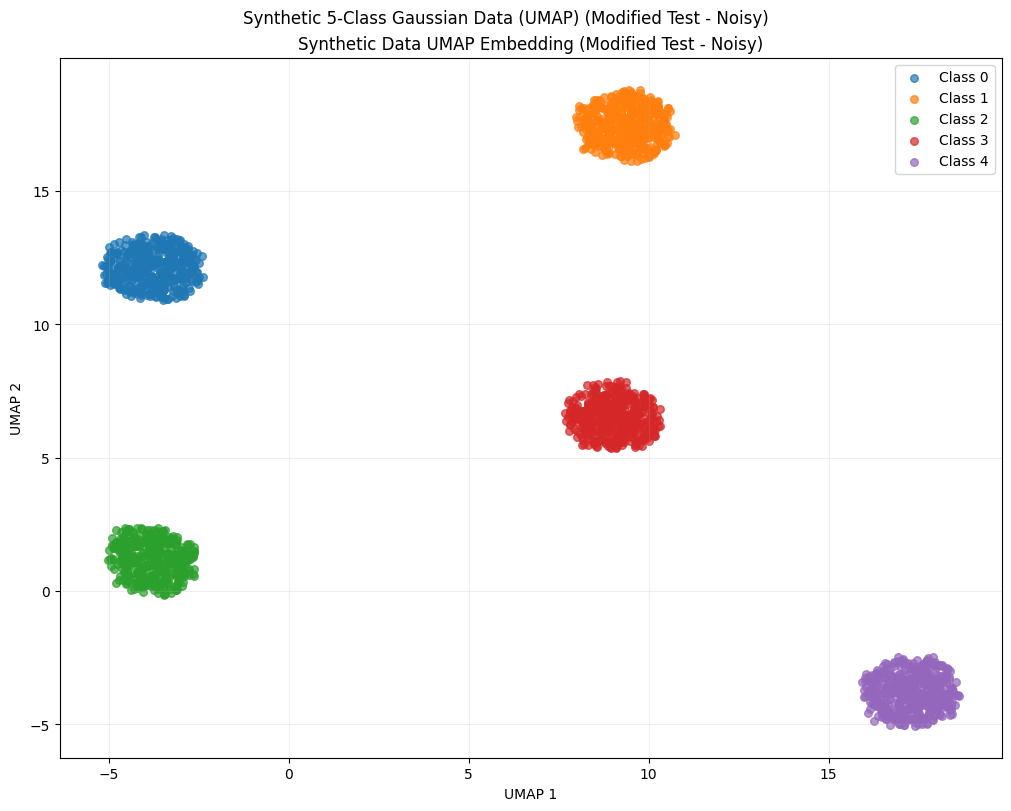

UMAP embedding shape: (2000, 2)
Data points per class: [399 418 377 387 419]


=== Mean Comparison ===
Original means (first 3 dims):
  Class 0: [ 0.49671415 -0.1382643   0.64768854]
  Class 1: [-0.56228753 -1.01283112  0.31424733]
  Class 2: [-0.60170661  1.85227818 -0.01349722]
  Class 3: [-0.71984421 -0.46063877  1.05712223]
  Class 4: [-0.47917424 -0.18565898 -1.10633497]

Modified means (first 3 dims):
  Class 0: [ 0.49671415 -0.1382643   0.64768854]
  Class 1: [-0.56228753 -1.01283112  0.31424733]
  Class 2: [-0.60170661  1.85227818 -0.01349722]
  Class 3: [-0.71984421 -0.46063877  1.05712223]
  Class 4: [-0.14235884  2.05722174  0.28326194]

Removed class 4 and added new class 4


In [4]:
# Create a new test set by removing one mean and adding a new one
print("=== Creating Modified Test Set ===")

# Remove one mean (let's remove class 4) and add a new one
modified_means = means.copy()
removed_class = 4
np.random.seed(99)
new_mean = np.random.randn(15)

print(f"Removing class {removed_class}")
print(f"Original mean for class {removed_class}: {means[removed_class][:5]}... (first 5 dims)")

# Remove the selected class and add the new mean
modified_means.pop(removed_class)
modified_means.append(new_mean)

print(f"New mean added: {new_mean[:5]}... (first 5 dims)")
print(f"Modified means now has {len(modified_means)} classes")

# Keep the same variance structure (remove corresponding variance and add new one)
modified_variance = variance.copy()
modified_variance.pop(removed_class)
modified_variance.append([.3] * 15)  # Same variance as original classes

# Generate new test data with modified means
np.random.seed(123)  # Different seed for test set

n_test_samples = 2000  # Smaller test set
n_modified_classes = len(modified_means)

# Equal probability for all 5 classes (but now with different means)
modified_class_probs = [1/n_modified_classes] * n_modified_classes

test_labels_modified = np.random.choice(range(n_modified_classes), size=n_test_samples, p=modified_class_probs)

print(f"Modified test class distribution: {np.bincount(test_labels_modified)}")

# Generate data using multivariate normal distribution with modified means
modified_test_data = []
modified_test_labels = []

for i in range(n_modified_classes):
    # Number of samples for this class
    n_class_samples = (test_labels_modified == i).sum()
    
    # Create covariance matrix (diagonal matrix from variances)
    cov_matrix = np.diag(modified_variance[i])
    
    # Sample from multivariate normal distribution
    class_data = np.random.multivariate_normal(
        mean=modified_means[i], 
        cov=cov_matrix, 
        size=n_class_samples
    )
    
    modified_test_data.append(class_data)
    modified_test_labels.append(np.full(n_class_samples, i))
    
    print(f"Modified Class {i}: {n_class_samples} samples")
    if i < len(means) - 1 and i != removed_class:
        original_idx = i if i < removed_class else i + 1
        print(f"  Corresponds to original class {original_idx}")
    elif i == len(modified_means) - 1:
        print(f"  NEW CLASS (not in training)")

# Create U matrix for modified test data
U_test_modified = np.vstack(modified_test_data)

# Use the SAME V matrix as training (this is key!)
X_test_modified = U_test_modified @ V.T

# Create labels array
y_test_modified = np.concatenate(modified_test_labels)

# Shuffle the modified test data
shuffle_idx = np.random.permutation(len(X_test_modified))
X_test_modified = X_test_modified[shuffle_idx]
y_test_modified = y_test_modified[shuffle_idx]

# Add noise (same level as original test set)
X_test_modified_noisy = X_test_modified + np.random.normal(0, 1, X_test_modified.shape)

print(f"\n=== Modified Test Set Summary ===")
print(f"X_test_modified_noisy shape: {X_test_modified_noisy.shape}")
print(f"y_test_modified shape: {y_test_modified.shape}")
print(f"Unique labels: {np.unique(y_test_modified)}")
print(f"Label distribution: {np.bincount(y_test_modified)}")

# Visualize the modified test set
visualize_umap(X_test_modified_noisy, y_test_modified, "(Modified Test - Noisy)")

# Compare original vs modified means
print(f"\n=== Mean Comparison ===")
print("Original means (first 3 dims):")
for i, mean in enumerate(means):
    print(f"  Class {i}: {mean[:3]}")

print("\nModified means (first 3 dims):")
for i, mean in enumerate(modified_means):
    print(f"  Class {i}: {mean[:3]}")
    
print(f"\nRemoved class {removed_class} and added new class {len(modified_means)-1}")

In [5]:
# Save the modified test set
print("=== Saving Modified Test Set ===")

# Save modified test data 
np.save('C_test_modified.npy', X_test_modified_noisy)

# Save modified test labels
labels_test_modified_df = pd.DataFrame({'x': y_test_modified})
labels_test_modified_df.to_csv('labels_test_modified.csv', index=False)

print(f"Classes 0-{removed_class-1} stay the same, class {removed_class} removed, classes {removed_class}-{len(means)-2} shifted down by 1, new class {len(modified_means)-1} added")


=== Saving Modified Test Set ===
Classes 0-3 stay the same, class 4 removed, classes 4-3 shifted down by 1, new class 4 added


=== Creating 6-Class Reference Dataset ===
Reference dataset will have 6 classes
Reference class distribution: [203 198 193 219 195 192]
Reference class proportions: [0.16916667 0.165      0.16083333 0.1825     0.1625     0.16      ]
Reference Class 0: 203 samples
  Mean (first 3 dims): [ 0.49671415 -0.1382643   0.64768854]
  Same as original training class 0
Reference Class 1: 198 samples
  Mean (first 3 dims): [-0.56228753 -1.01283112  0.31424733]
  Same as original training class 1
Reference Class 2: 193 samples
  Mean (first 3 dims): [-0.60170661  1.85227818 -0.01349722]
  Same as original training class 2
Reference Class 3: 219 samples
  Mean (first 3 dims): [-0.71984421 -0.46063877  1.05712223]
  Same as original training class 3
Reference Class 4: 195 samples
  Mean (first 3 dims): [-0.47917424 -0.18565898 -1.10633497]
  Same as original training class 4
Reference Class 5: 192 samples
  Mean (first 3 dims): [-0.14235884  2.05722174  0.28326194]
  Same as NEW class from modified 

/opt/homebrew/anaconda3/envs/mixed_diffusion/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/anaconda3/envs/mixed_diffusion/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


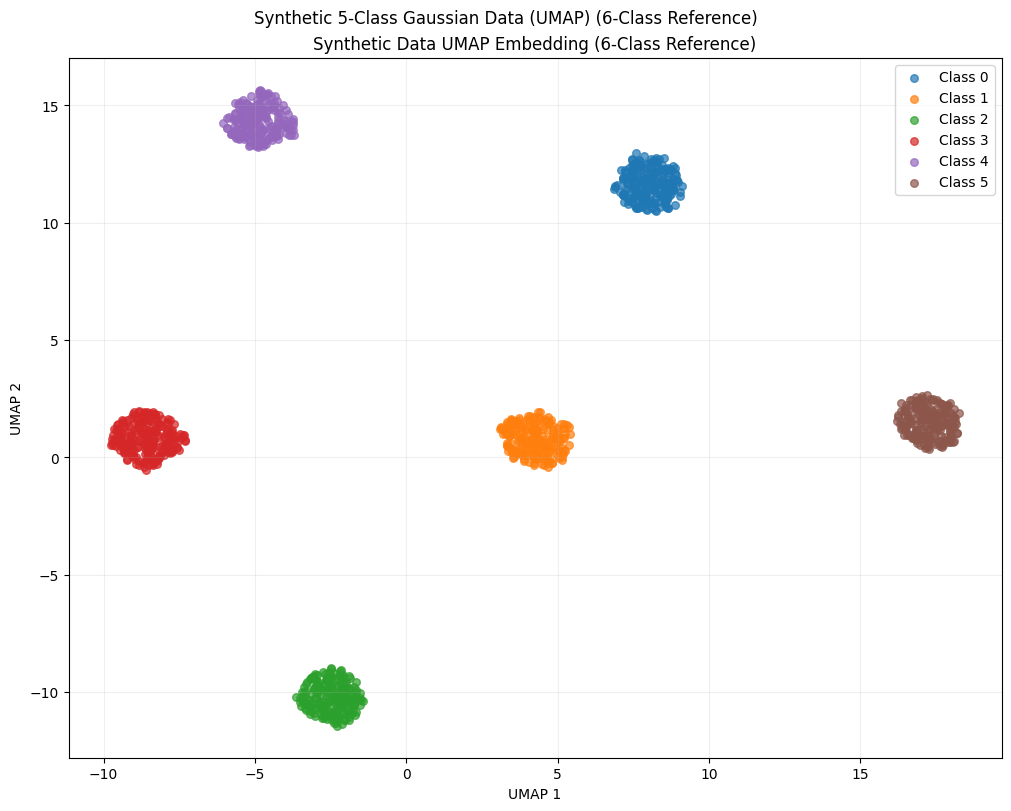

UMAP embedding shape: (1200, 2)
Data points per class: [203 198 193 219 195 192]


=== Reference Means Summary ===
All 6 reference means (first 3 dims):
  Class 0: [ 0.49671415 -0.1382643   0.64768854]
  Class 1: [-0.56228753 -1.01283112  0.31424733]
  Class 2: [-0.60170661  1.85227818 -0.01349722]
  Class 3: [-0.71984421 -0.46063877  1.05712223]
  Class 4: [-0.47917424 -0.18565898 -1.10633497]
  Class 5: [-0.14235884  2.05722174  0.28326194]

This 6-class reference includes:
- All 5 original training classes (0-4)
- 1 additional class (5) - same as the NEW class from modified test set
- Can be used as UMAP reference for comparison


In [6]:
# Generate a 6-class reference dataset for UMAP reference
print("=== Creating 6-Class Reference Dataset ===")

# Create 6 different means for reference (includes original 5 + 1 more)
reference_means = means.copy()  # Original 5 classes
reference_means.append(new_mean)  # Add 6th class (same as the new class from modified test set)

# Same variance structure for all classes
reference_variance = [[.3] * 15 for _ in range(6)]

print(f"Reference dataset will have {len(reference_means)} classes")

# Generate reference data
np.random.seed(999)  # Different seed for reference set

n_reference_samples = 1200  # Larger reference set for better UMAP
n_reference_classes = len(reference_means)

# Equal probability for all 6 classes
reference_class_probs = [1/n_reference_classes] * n_reference_classes

reference_labels = np.random.choice(range(n_reference_classes), size=n_reference_samples, p=reference_class_probs)

print(f"Reference class distribution: {np.bincount(reference_labels)}")
print(f"Reference class proportions: {np.bincount(reference_labels) / n_reference_samples}")

# Generate data using multivariate normal distribution
reference_data = []
reference_labels_list = []

for i in range(n_reference_classes):
    # Number of samples for this class
    n_class_samples = (reference_labels == i).sum()
    
    # Create covariance matrix (diagonal matrix from variances)
    cov_matrix = np.diag(reference_variance[i])
    
    # Sample from multivariate normal distribution
    class_data = np.random.multivariate_normal(
        mean=reference_means[i], 
        cov=cov_matrix, 
        size=n_class_samples
    )
    
    reference_data.append(class_data)
    reference_labels_list.append(np.full(n_class_samples, i))
    
    print(f"Reference Class {i}: {n_class_samples} samples")
    print(f"  Mean (first 3 dims): {np.array(reference_means[i])[:3]}")
    if i < 5:
        print(f"  Same as original training class {i}")
    else:
        print(f"  Same as NEW class from modified test set")

# Create U matrix for reference data
U_reference = np.vstack(reference_data)

# Use the SAME V matrix as training (crucial for consistency!)
X_reference = U_reference @ V.T

# Create labels array
y_reference = np.concatenate(reference_labels_list)

# Shuffle the reference data
shuffle_idx = np.random.permutation(len(X_reference))
X_reference = X_reference[shuffle_idx]
y_reference = y_reference[shuffle_idx]

# Add noise (same level as training set for reference)
X_reference_noisy = X_reference + np.random.normal(0, 0.5, X_reference.shape)

print(f"\n=== 6-Class Reference Set Summary ===")
print(f"X_reference_noisy shape: {X_reference_noisy.shape}")
print(f"y_reference shape: {y_reference.shape}")
print(f"Unique labels: {np.unique(y_reference)}")
print(f"Label distribution: {np.bincount(y_reference)}")

# Visualize the 6-class reference set
visualize_umap(X_reference_noisy, y_reference, "(6-Class Reference)")

print(f"\n=== Reference Means Summary ===")
print("All 6 reference means (first 3 dims):")
for i, mean in enumerate(reference_means):
    print(f"  Class {i}: {mean[:3]}")
    
print(f"\nThis 6-class reference includes:")
print(f"- All 5 original training classes (0-4)")
print(f"- 1 additional class (5) - same as the NEW class from modified test set")
print(f"- Can be used as UMAP reference for comparison")

In [7]:
# Save the 6-class reference dataset
print("=== Saving 6-Class Reference Dataset ===")

# Save reference data
np.save('C_reference_6class.npy', X_reference_noisy)

# Save reference labels
labels_reference_df = pd.DataFrame({'x': y_reference})
labels_reference_df.to_csv('labels_reference_6class.csv', index=False)

# Save the reference means for future use
reference_means_array = np.array(reference_means)
np.save('reference_means_6class.npy', reference_means_array)


=== Saving 6-Class Reference Dataset ===


In [8]:
# Save V
print(V.shape)
np.save("V.npy", V)

(200, 15)


In [9]:
# Load and visualize a result using the reference UMAP
print("=== Loading and Visualizing Results with Reference UMAP ===")

# Load some result data (assuming you have generated/saved results)
# For demonstration, let's use the modified test set as an example result
results = torch.load("/Users/dm954/Documents/code/mixed_diffusion/results/synthetic_archetypes/medium/15pca_latent/gibbs200_rho0.1-0.1_rep10/denoising_results.pt", weights_only=False, map_location='cpu')
result_data = results["x_denoised"]
result_labels = results["x_denoised_labels"]

# Load the reference data for UMAP fitting
reference_data = X_reference_noisy
reference_labels = y_reference

print(f"Reference data shape: {reference_data.shape}")
print(f"Result data shape: {result_data.shape}")

# Apply PCA first to both reference and result data
pca = PCA(n_components=15)
reference_pca = pca.fit_transform(reference_data)

# Fit UMAP on the reference data
um = umap.UMAP(n_neighbors=15, min_dist=0.3, random_state=0)
reference_embedding = um.fit_transform(reference_pca)

# Transform the result data using the fitted UMAP
result_embedding = um.transform(result_data)

# Plot both reference and result data
fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)

import matplotlib.colors as mcolors
palette = list(mcolors.TABLEAU_COLORS.values())

# Plot 1: Reference data only
ax1 = axes[0]
ax1.set_title("Reference Data (6 Classes)")
unique_ref_labels = np.unique(reference_labels)
for i, label in enumerate(unique_ref_labels):
    mask = reference_labels == label
    ax1.scatter(reference_embedding[mask, 0], reference_embedding[mask, 1], 
               s=30, alpha=0.7, 
               c=palette[i % len(palette)], 
               label=f'Ref Class {label}')
ax1.set_xlabel("UMAP 1")
ax1.set_ylabel("UMAP 2")
ax1.grid(True, alpha=0.2)
ax1.legend()

# Plot 2: Result data only  
ax2 = axes[1]
ax2.set_title("Result Data (Modified Test Set)")
unique_result_labels = np.unique(result_labels)
for i, label in enumerate(unique_result_labels):
    mask = result_labels == label
    ax2.scatter(result_embedding[mask, 0], result_embedding[mask, 1], 
               s=30, alpha=0.7, 
               c=palette[i % len(palette)], 
               label=f'Result Class {label}')
ax2.set_xlabel("UMAP 1")
ax2.set_ylabel("UMAP 2")
ax2.grid(True, alpha=0.2)
ax2.legend()

# Plot 3: Both overlaid
ax3 = axes[2]
ax3.set_title("Reference + Result Overlay")

# Plot reference data with lighter colors
for i, label in enumerate(unique_ref_labels):
    mask = reference_labels == label
    ax3.scatter(reference_embedding[mask, 0], reference_embedding[mask, 1], 
               s=20, alpha=0.3, 
               c=palette[i % len(palette)], 
               label=f'Ref-{label}')

# Plot result data with darker colors and different markers
for i, label in enumerate(unique_result_labels):
    mask = result_labels == label
    ax3.scatter(result_embedding[mask, 0], result_embedding[mask, 1], 
               s=40, alpha=0.8, marker='x',
               c=palette[i % len(palette)], 
               label=f'Res-{label}')

ax3.set_xlabel("UMAP 1")
ax3.set_ylabel("UMAP 2")
ax3.grid(True, alpha=0.2)
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle("UMAP Visualization: Reference vs Result Data")
plt.show()

print(f"\nVisualization Summary:")
print(f"- Reference embedding shape: {reference_embedding.shape}")
print(f"- Result embedding shape: {result_embedding.shape}")
print(f"- Reference classes: {np.unique(reference_labels)}")
print(f"- Result classes: {np.unique(result_labels)}")
print(f"- Classes 0-4 should align between reference and result")
print(f"- Class 5 in reference corresponds to class 4 in result (new class)")
print(f"- Class 5 in reference corresponds to class 4 in result (new class)")

=== Loading and Visualizing Results with Reference UMAP ===


FileNotFoundError: [Errno 2] No such file or directory: '/Users/dm954/Documents/code/mixed_diffusion/results/synthetic_archetypes/medium/15pca_latent/gibbs200_rho0.1-0.1_rep10/denoising_results.pt'

In [ ]:
def visualize_umap(X, y, points_to_plot=None, labels_to_plot=None):
    # --- UMAP visualization of synthetic data ---
    # Apply PCA first to reduce dimensionality
    pca = PCA(n_components=15)
    X_pca = pca.fit_transform(X)

    # Then apply UMAP on the PCA-reduced data
    um = umap.UMAP(n_neighbors=15, min_dist=0.3, random_state=0, metric="cosine").fit(X_pca)
    emb = um.embedding_

    if points_to_plot is not None:
        emb = um.transform(pca.transform(points_to_plot))
        y = np.array(labels_to_plot)

    # --- Plot the UMAP embedding ---
    fig, ax = plt.subplots(1, 1, figsize=(8, 6), constrained_layout=True)
    ax.set_title("Synthetic Data UMAP Embedding")

    import matplotlib.colors as mcolors
    palette = list(mcolors.TABLEAU_COLORS.values())

    # Plot each class with different colors
    unique_labels = np.unique(y)
    for i, label in enumerate(unique_labels):
        mask = y == label
        ax.scatter(emb[mask, 0], emb[mask, 1], 
                s=20, alpha=0.7, 
                c=palette[i % len(palette)], 
                label=f'Class {label}')

    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.grid(True, alpha=0.2)
    ax.legend()

    plt.suptitle("Synthetic 2-Class Gaussian Data (UMAP)")
    plt.show()


['alpha_0', 'alpha_10', 'alpha_20', 'alpha_30', 'alpha_40', 'alpha_50', 'alpha_60', 'alpha_70', 'alpha_80', 'alpha_90', 'alpha_100']
[[-5.62287529e-01 -1.01283112e+00  3.14247333e-01 -9.08024076e-01
  -1.41230370e+00  1.46564877e+00 -2.25776300e-01  6.75282047e-02
  -1.42474819e+00 -5.44382725e-01  1.10922590e-01 -1.15099358e+00
   3.75698018e-01 -6.00638690e-01 -2.91693750e-01]
 [-4.56387361e-01 -9.25374438e-01  3.47591453e-01 -6.64918682e-01
  -1.29448867e+00  1.29567020e+00 -4.52773889e-02  1.37518857e-01
  -1.32922081e+00 -4.35688448e-01  5.34885615e-02 -1.08246720e+00
   3.62324444e-01 -7.31902845e-01 -4.35016158e-01]
 [-3.50487193e-01 -8.37917757e-01  3.80935574e-01 -4.21813289e-01
  -1.17667364e+00  1.12569162e+00  1.35221523e-01  2.07509510e-01
  -1.23369343e+00 -3.26994171e-01 -3.94546679e-03 -1.01394081e+00
   3.48950869e-01 -8.63167001e-01 -5.78338566e-01]
 [-2.44587025e-01 -7.50461075e-01  4.14279694e-01 -1.78707896e-01
  -1.05885860e+00  9.55713051e-01  3.15720434e-01  2.7

/opt/homebrew/anaconda3/envs/mixed_diffusion/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


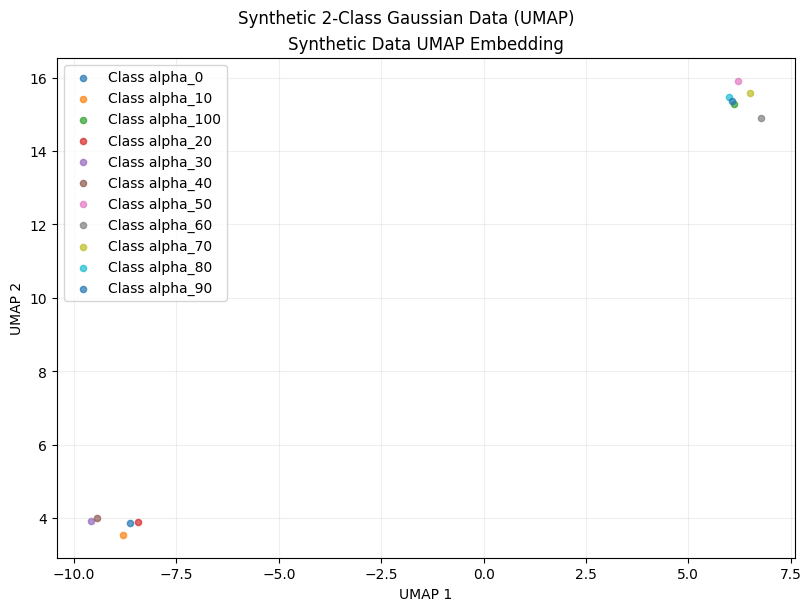

In [ ]:
mean_i = np.array(means[0])
mean_j = np.array(means[1])

interpolated_data = []
interpolated_label = []
for alpha in np.arange(0.0, 1.1, 0.1):
    interpolated_point = mean_i * alpha + (1-alpha) * mean_j
    
    interpolated_data.append(interpolated_point)
    interpolated_label.append(f"alpha_{int(alpha*100)}")
    
print(interpolated_label)

U = np.vstack(interpolated_data)
print(U)

X_interpolated = U @ V.T

print(f"U.shape: {U.shape}")
print(f"V.shape: {V.shape}")
print(f"X_interpolated.shape: {X_interpolated.shape}")

visualize_umap(X_train, interpolated_label, points_to_plot=X_interpolated, labels_to_plot=np.array(interpolated_label))

np.save('C_test_interpolated.npy', X_interpolated)
pd.DataFrame(interpolated_label).to_csv('labels_interpolated.csv', index=False)